## Import Library

In [1]:
import json
import random
import csv
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import pandas as pd
import itertools 

## Parameter Awal

In [17]:
tds_goal = 600  # ppm berdasarkan kebutuhan tanaman cabai
initial_tds_nutrisi = 2000  # ppm, tds awal nutrisi
max_air = 400 # ppm, batas rentang tds air
tolerance_nutrisi = 0.3 # variabel ini membuat batas rentang 30% rentang atas dan rentang bawah dari nilai awal tds nutrisi (1400 - 2600 ppm)
flow_rate_air = 10  # ml/s (dan juga sebagai step/bin untuk volume) diskretisasi
flow_rate_nutrisi = 10  # ml/s (dan juga sebagai step/bin untuk volume) diskretisasi
total_vol = 750 # volume target maksimum dari campuran air dan nutrisi

toleransi_volume = total_vol - 100  # ml, toleransi volume target

# Parameter Q-Learning
learning_rate = 0.1
discount_factor = 0.9
epsilon = 1.0

# Decay rate disesuaikan untuk iterasi yang banyak, akan berkurang secara eksponen terhadap jumlah iterasi.
epsilon_decay = 0.9999998 

# untuk mencegah nilai e yang terus berkurang mendekati nol, maka ditentukan batas minimum e
epsilon_min = 0.1

# Pengaturan diskretisasi State Space
step_air = 3 # mengubah data kontinu menjadi diskret interval 3
step_nutrisi = 10 # mengubah data kontinu menjadi diskret interval 10

# Variabel Global untuk menyimpan data visualisasi dan hasil
all_rewards = []
cumulative_rewards = []
best_results = {}

### Membuat rentang untuk action (agar tidak terlalu kompleks)

Masing-masing action harus mencapai "total_vol" yaitu 750 ml untuk masa vegetatif, 1500 ml untuk masa pertumbuhan awal daun dan generatif. Secara deafult, masing-masing action memiliki rentang dari 0 - total volume. Berarti ada kondisi dimana agen mencoba (action air, action nutrisi) yaitu (0,0), maka total volume adalah nol, atau misal (50,100) berarti total volume 150ml, jauh dari target. 

Jika agen mempelajari semua kondisi itu maka akan membebani model Q-learning, Q table membengkak. Untuk mengatasi itu maka dibuat rentang minimum dan maksimum untuk masing2 action yang akan dipelajari (Valid action). Rentang kondisi action air dan action nutrisi dapat ditentukan dari perhitungan matematis, dengn memperkirakan ketika salah satu komponen lebih dominan. yaitu di kondisi minimum untuk kedua state dari rentang yang di tentukan yaitu di state (1, 1400), dan di kondisi maksimum kedua state yaitu (400, 2600).

In [3]:
# Fungsi untuk mencari rentang min dan max action
def cariRentang(tdsAir, tdsNutrisi):
   Vn = total_vol *(tds_goal - tdsAir)/(tdsNutrisi - tdsAir)
   Va = total_vol -Vn
   print(f"volume air {Va}, volume nutrisi {Vn}")
   
cariRentang(1, 1400)
cariRentang(400, 2600)

volume air 428.87776983559684, volume nutrisi 321.12223016440316
volume air 681.8181818181818, volume nutrisi 68.18181818181819



jadi rentang minimum air dan maksimum nutrisi didapat ketika kondisi ekstrim tds air 1 ppm dan nutrisi 1400 ppm (kondisi dalam batas minimum, input air (1-400) dan nutrisi(1400-2600))

rentang maksimum air dan minimum nutrisi didapat ketika kondisi ekstrim tds air 400 ppm dan nutrisi 2600 ppm (kondisi dalam batas maksimum, input air (1-400) dan nutrisi(1400-2600))

In [4]:
# Dibulatkan
min_air_vol = 400
max_nutrisi_vol = 350

max_air_vol = 700
min_nutrisi_vol = 50

## Menentukan banyak iterasi, dari Total pasangan State x action yang telah di diskretisasi

In [ ]:
tds_air_range = range(1, int(max_air) + 1, step_air)
tds_nutrisi_range = range(int(initial_tds_nutrisi * (1 - tolerance_nutrisi)), 
                        int(initial_tds_nutrisi * (1 + tolerance_nutrisi)) + 1, step_nutrisi)
air_actions_range = range(min_air_vol, max_air_vol + 1, flow_rate_air)
nutrisi_actions_range = range(min_nutrisi_vol, max_nutrisi_vol + 1, flow_rate_nutrisi)

all_state = list(itertools.product(tds_air_range, tds_nutrisi_range))
all_actions_initial = list(itertools.product(air_actions_range, nutrisi_actions_range))

print(f"Jumlah state: {len(all_state)}")
print(f"Jumlah aksi awal (sebelum reduksi): {len(all_actions_initial)}")

# Terapkan filter Action Pruning berdasarkan total volume
valid_actions = []
for action in all_actions_initial:
   vol_air, vol_nutrisi = action
   total_campuran = vol_air + vol_nutrisi
   # Hanya simpan aksi jika total volume antara rentang toleransi
   if toleransi_volume <= total_campuran <= total_vol:
      valid_actions.append(action)

# Gunakan daftar aksi yang sudah valid untuk pelatihan
actions = valid_actions

# Total anggota state-action
total_aksi_setelah_reduksi = len(actions)
total_pasangan = list(itertools.product(all_state, actions))
print(f"Jumlah aksi setelah reduksi: {total_aksi_setelah_reduksi}")
print(f"Total pasangan state x action: {len(total_pasangan)}")

Jumlah state: 16214
Jumlah aksi awal (sebelum reduksi): 961
Jumlah aksi setelah reduksi: 286
Total pasangan state x action: 4637204


In [18]:
# iterasi bisa ditentukan dari total pasangan state x action (state, action)
max_iterations = 10000000 # dibulatkan

# semakin banyak iterasi maka memungkinkan agen untuk kembali belajar pasangan state-action yang sama, dan memperbarui Q value nya.
# Jumlah iterasi sebanyak total pasangan state x action sudah cukup, memungkinkan pembelajaran penuh semua kondisi di Q table.

## Fungsi Hitung TDS

In [7]:
def calculate_tds(volume_air, volume_nutrisi, tds_air, tds_nutrisi):
    total_volume = volume_air + volume_nutrisi
    if total_volume == 0:
        return 0
    return (volume_air * tds_air + volume_nutrisi * tds_nutrisi) / total_volume

## Fungsi Q-Learning

In [ ]:
def train_q_learning():
    global toleransi_volume, actions, tds_air_range, tds_nutrisi_range, air_actions_range, nutrisi_actions_range

    # tabel q untuk pelatihan (kebijakan optimal)
    q_table = {}

    # # Gunakan jika membutuhkan file log untuk analisis, file log bisa berukuran sangat besar.
    # # log urutan aksi untuk kebutuhan analisis
    # q_table_log = {}
    
    global all_rewards, cumulative_rewards, epsilon, best_results

    with open(f"output_iterasi_{tds_goal}.csv", mode="w", newline="") as csvfile_all:
        fieldnames = ["Iterasi", "TDS_Air", "TDS_Nutrisi", "TDS_Hasil", "Reward", "Action", "Total_Volume", "Q_Value"]
        writer_all = csv.DictWriter(csvfile_all, fieldnames=fieldnames)
        writer_all.writeheader()

        cumulative_reward = 0

        for iteration in range(max_iterations):
            tds_air = random.choice(tds_air_range)
            tds_nutrisi = random.choice(tds_nutrisi_range)
            state = (tds_air, tds_nutrisi)

            if state not in q_table:
                q_table[state] = np.zeros(len(actions))

            if random.uniform(0, 1) < epsilon:
                action_idx = random.choice(range(len(actions)))
            else:
                action_idx = np.argmax(q_table[state])

            action = actions[action_idx]
            volume_air, volume_nutrisi = action

            tds_campuran = calculate_tds(volume_air, volume_nutrisi, tds_air, tds_nutrisi)
            total_campuran = volume_air + volume_nutrisi

            reward = -abs(tds_goal - tds_campuran) - abs(total_vol - total_campuran) * 0.1
            cumulative_reward += reward

            next_tds_air = random.choice(tds_air_range)
            next_tds_nutrisi = random.choice(tds_nutrisi_range)
            next_state = (next_tds_air, next_tds_nutrisi)

            old_value = q_table[state][action_idx]
            new_q = (1 - learning_rate) * old_value + learning_rate * (reward + discount_factor * np.max(q_table.get(next_state, np.zeros(len(actions)))))
            q_table[state][action_idx] = new_q

            # # Gunakan jika membutuhkan file log untuk analisis, file log bisa berukuran sangat besar.
            # # ctrl + /
            # # Jika state ini baru pertama kali dikunjungi, buat list kosong 
            # if state not in q_table_log:
            #     q_table_log[state] = []

            # # fungsi untuk mencatat setiap pembaruan secara berurutan
            # q_table_log[state].append({
            #     "action": action,
            #     "q_value": round(new_q, 4)
            # })

            result = {  
                "Iterasi": iteration,
                "TDS_Air": tds_air,
                "TDS_Nutrisi": tds_nutrisi,
                "TDS_Hasil": round(tds_campuran, 2),
                "Reward": round(reward, 2),
                "Action": action,
                "Total_Volume": total_campuran,
                "Q_Value": round(new_q, 4)
            }
            
            writer_all.writerow(result)

            if state not in best_results or reward > best_results[state]["Reward"]:
                best_results[state] = result
                best_results[state]["Q_Value"] = new_q

            if iteration % 5000 == 0:
                print(f"Iteration: {iteration}, State: {state}, Action: {action}, Q Value: {new_q}, Reward: {reward}, TDS Campuran: {tds_campuran}, Total Volume: {total_campuran}")

            all_rewards.append(reward)
            cumulative_rewards.append(cumulative_reward)

            epsilon = max(epsilon * epsilon_decay, epsilon_min)

        with open(f"q_table_best_{tds_goal}.json", "w") as json_file:
            json.dump({str(key): value for key, value in best_results.items()}, json_file)
        
        with open(f"Output_iterasi_terbaik_{tds_goal}.csv", mode="w", newline="") as csvfile_best:
            fieldnames = ["State", "TDS_Air", "TDS_Nutrisi", "TDS_Hasil", "Reward", "Action", "Total_Volume", "Q_Value"]
            writer_best = csv.DictWriter(csvfile_best, fieldnames=fieldnames)
            writer_best.writeheader()

            for state, best_result in best_results.items():
                writer_best.writerow({
                    "State": state,
                    "TDS_Air": best_result["TDS_Air"],
                    "TDS_Nutrisi": best_result["TDS_Nutrisi"],
                    "TDS_Hasil": best_result["TDS_Hasil"],
                    "Reward": best_result["Reward"],
                    "Action": best_result["Action"],
                    "Total_Volume": best_result["Total_Volume"],
                    "Q_Value": best_result.get("Q_Value", 0)
                })
                
# # Gunakan jika membutuhkan file log untuk analisis, file log bisa berukuran sangat besar.
# # -----------------------------------------------------------------
#         print("\nMembuat laporan Q-Table kronologis...")

#         # Menentukan nama file output (disarankan beri nama baru)
#         nama_file_log = f"q_table_log_{tds_goal}.json"

#         # Konversi kunci 'state' (yang merupakan tuple) menjadi string agar valid untuk JSON
#         report_data = {str(state): history for state, history in q_table_log.items()}

#         # Menulis dictionary yang sudah tercatat secara kronologis ke file
#         with open(nama_file_log, "w") as json_file_report:
#             json.dump(report_data, json_file_report, indent=4)

#         print(f"Laporan log Q-Table telah disimpan ke: {nama_file_log}")
# # -----------------------------------------------------------------
#         print(f"Q-Table telah disimpan ke: {nama_file_log}")
#         print("Training selesai!")
        
    return q_table, actions

## Visualisasi Hasil

In [ ]:
def visualize_results_from_csv(tds_goal):
    try:
        # file yang akan dibaca
        file_iterasi = f"{tds_goal}ppm 5jt\Output_iterasi_terbaik_{tds_goal}.csv"
        # file_q_table = f"q_table_utuh_{tds_goal}.csv"
        
        print(f"Memuat data dari: {file_iterasi} ...")

        df_q_table = pd.read_csv(file_iterasi)
        
        # 'best_results' adalah baris dengan Q-value maksimum untuk setiap state
        idx = df_q_table.groupby(['TDS_Air', 'TDS_Nutrisi'])['Reward'].idxmax()
        df_best = df_q_table.loc[idx]

        # ==========================================================
        # --- SOLUSI: ACAK (SHUFFLE) DATAFRAME SEBELUM PLOTTING ---
        # Ini akan menghilangkan urutan implisit yang dibuat oleh groupby
        # dan menunjukkan distribusi yang sebenarnya.
        df_best_shuffled = df_best.sample(frac=1).reset_index(drop=True)
        # ==========================================================

        # ==========================================================
        # Grafik Reward untuk Setiap Iterasi Terbaik
        # ==========================================================
        plt.figure(figsize=(14, 8))

        # Gunakan df_best_shuffled untuk perhitungan dan plotting
        average_reward = df_best_shuffled['Reward'].mean() 
        
        plt.tick_params(axis='both', which='major', labelsize=14)
        plt.scatter(range(len(df_best_shuffled)), df_best_shuffled['Reward'], label="Reward Terbaik per State (Diacak)", color="blue", alpha=0.4)
        plt.axhline(y=average_reward, color='red', linestyle='--', label=f"Rata-rata Reward Terbaik: {average_reward:.2f}")
        
        plt.title("Distribusi Reward Terbaik untuk Setiap State yang Dilatih", fontsize=18)
        plt.xlabel("Indeks State (Acak)", fontsize=15)
        plt.ylabel("Reward Terbaik", fontsize=15)
        plt.legend(fontsize=15)
        plt.grid()
        plt.show()

        # ==========================================================
        # Grafik Hubungan antara Parameter terhadap TDS Goals
        # ==========================================================

        # 1. Hitung kepadatan untuk setiap koordinat unik
        density = df_q_table.groupby(['Total_Volume', 'TDS_Hasil']).size().reset_index(name='count')

        # Membuat plot
        fig, ax = plt.subplots(figsize=(16, 9))

        # Membuat Bubble Chart
        # 's' adalah ukuran, kita kalikan dengan angka (misal 20) agar perbedaannya terlihat jelas
        # Atur rentang colormap manual agar titik dengan count rendah tetap terlihat biru
        cmap_biru = mpl.cm.get_cmap('Blues', 256)
        new_cmap = mpl.colors.LinearSegmentedColormap.from_list(
            "Blues_trimmed", cmap_biru(np.linspace(0.5, 1.0, 256))
        )

        # Scatter dengan colormap hasil trimming
        scatter = ax.scatter(
            density['Total_Volume'],
            density['TDS_Hasil'],
            s=density['count'] * 20,
            alpha=0.7,
            c=density['count'],
            cmap=new_cmap,      # pakai colormap baru
            vmin=density['count'].min(),
            vmax=density['count'].max()
        )

        cbar = fig.colorbar(scatter)
        cbar.set_label('Jumlah Anggota (Kepadatan)', fontsize=15)

        ax.axhline(y=tds_goal, color="red", linestyle="--", label=f"TDS Goal ({tds_goal} ppm)")

        # Judul dan label
        ax.set_title("Distribusi Kepadatan TDS Hasil vs. Total Volume", fontsize=18)
        ax.set_xlabel("Total Volume (ml)", fontsize=15)
        ax.set_ylabel("TDS Hasil (ppm)", fontsize=15)
        ax.legend(fontsize=15)
        ax.grid(True)
        ax.tick_params(axis='both', which='major', labelsize=14)

        plt.show()

        # ==========================================================
        # Persiapan data untuk plot #2 dan #4 dari file Q-Table
        # ==========================================================
        df_q_table = pd.read_csv(file_iterasi)
        
        # 'best_results' adalah baris dengan Q-value maksimum untuk setiap state
        idx = df_q_table.groupby(['TDS_Air', 'TDS_Nutrisi'])['Q_Value'].idxmax()
        df_best = df_q_table.loc[idx]

        # ==========================================================
        # Grafik Reward untuk Setiap Iterasi Terbaik
        # ==========================================================
        plt.figure(figsize=(14, 8))

        # Gunakan df_best_shuffled untuk perhitungan dan plotting
        average_Q_Value = df_best_shuffled['Q_Value'].mean() 
        
        plt.scatter(range(len(df_best_shuffled)), df_best_shuffled['Q_Value'], label="Q_Value Terbaik per State (Diacak)", color="purple", alpha=0.4)
        plt.axhline(y=average_Q_Value, color='red', linestyle='--', label=f"Rata-rata Q_Value Terbaik: {average_Q_Value:.2f}")
        
        plt.title("Distribusi Q_Value Terbaik untuk Setiap State yang Dilatih", fontsize=18)
        plt.xlabel("Indeks State (Acak)", fontsize=15)
        plt.ylabel("Q_Value Terbaik", fontsize=15)
        plt.tick_params(axis='both', which='major', labelsize=14)
        plt.legend(fontsize=15)
        plt.grid()
        plt.show()

    except FileNotFoundError as e:
        print(f"Error: File tidak ditemukan! - {e}")
        print("Pastikan Anda sudah menjalankan sel pelatihan dan file CSV sudah dibuat.")
    except Exception as e:
        print(f"Terjadi error saat membuat visualisasi: {e}")
    except FileNotFoundError as e:
        print(f"Error: File tidak ditemukan! - {e}")
        print("Pastikan Anda sudah menjalankan sel pelatihan dan file CSV sudah dibuat.")
    except Exception as e:
        print(f"Terjadi error saat membuat visualisasi: {e}")

### Jalankan Pelatihan

In [19]:
q_table, actions = train_q_learning()

Iteration: 0, State: (61, 1980), Action: (580, 110), Q Value: -23.907246376811596, Reward: -239.07246376811594, TDS Campuran: 366.92753623188406, Total Volume: 690
Iteration: 5000, State: (187, 2000), Action: (590, 120), Q Value: -11.057746478873241, Reward: -110.57746478873241, TDS Campuran: 493.4225352112676, Total Volume: 710
Iteration: 10000, State: (1, 2280), Action: (570, 170), Q Value: -7.644594594594594, Reward: -76.44594594594594, TDS Campuran: 524.5540540540541, Total Volume: 740
Iteration: 15000, State: (169, 1560), Action: (500, 150), Q Value: -12.0, Reward: -120.0, TDS Campuran: 490.0, Total Volume: 650
Iteration: 20000, State: (307, 2240), Action: (680, 70), Q Value: -11.258666666666665, Reward: -112.58666666666664, TDS Campuran: 487.41333333333336, Total Volume: 750
Iteration: 25000, State: (190, 2470), Action: (640, 90), Q Value: -13.090410958904108, Reward: -130.90410958904107, TDS Campuran: 471.09589041095893, Total Volume: 730
Iteration: 30000, State: (16, 2320), Act

### Visualisasi

Memuat data dari: 600ppm 5jt\Output_iterasi_terbaik_600.csv ...


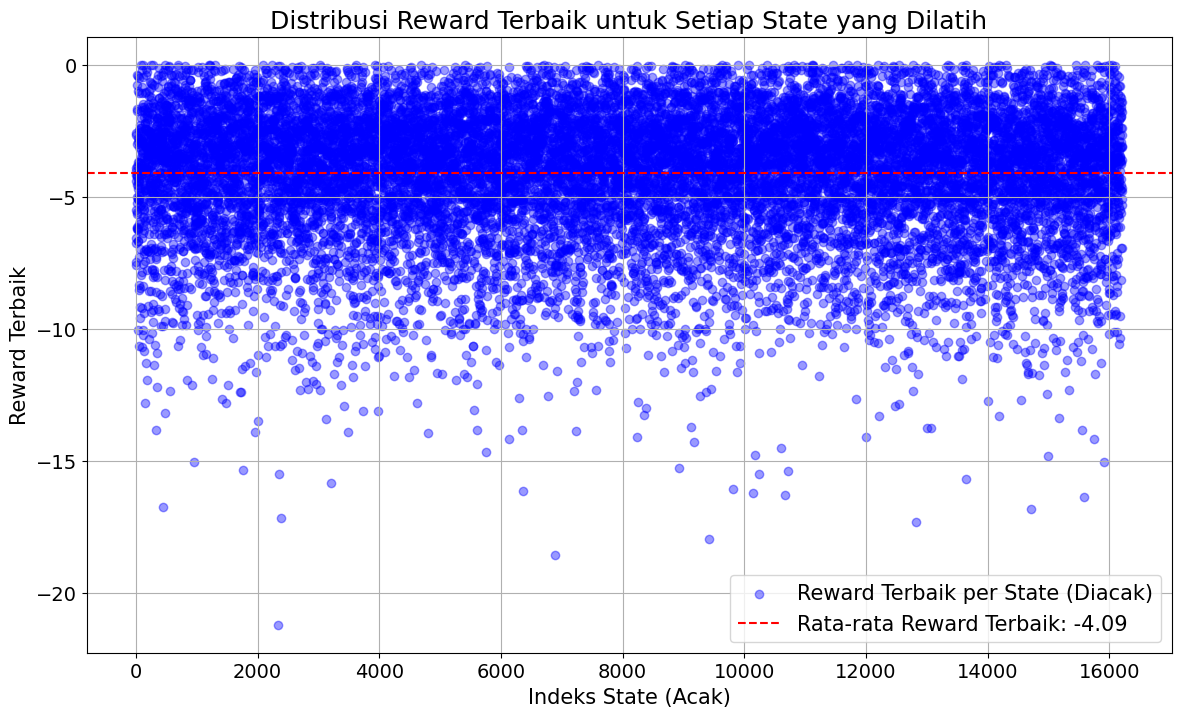

C:\Users\asus\AppData\Local\Temp\ipykernel_12760\585974329.py:54: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_biru = mpl.cm.get_cmap('Blues', 256)


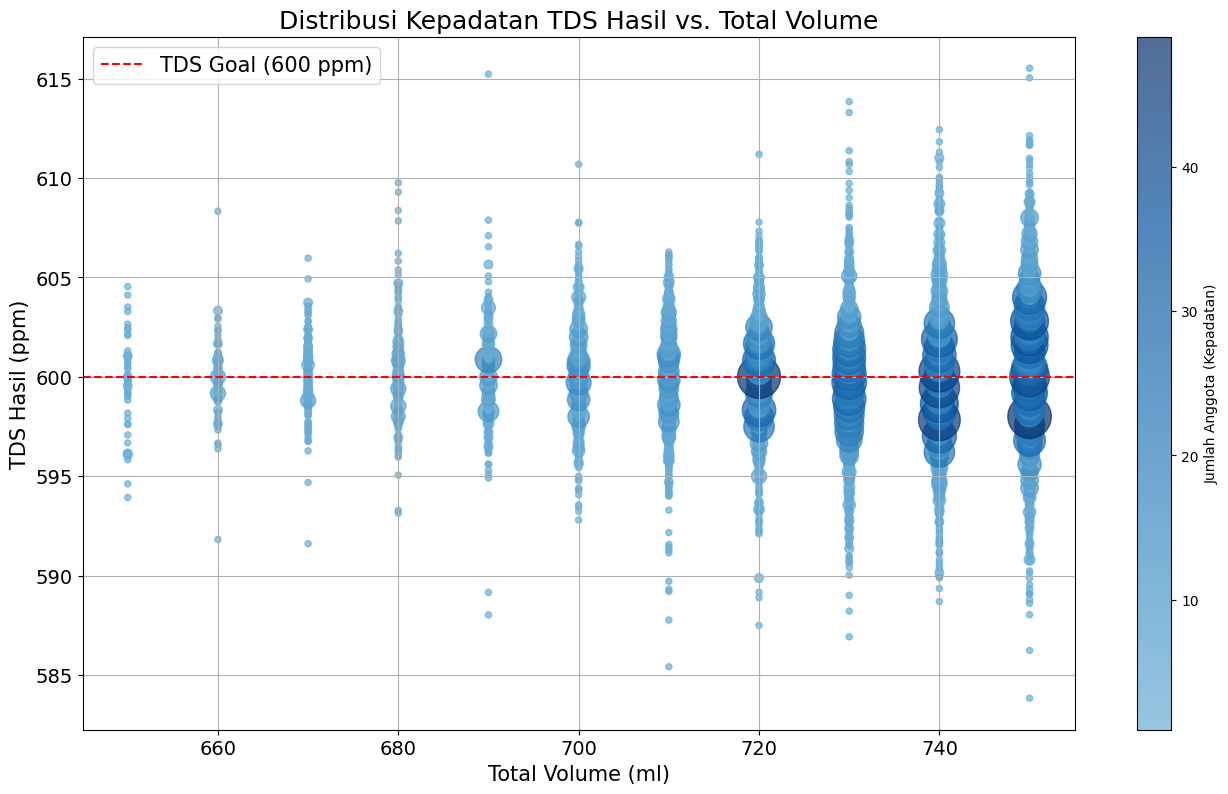

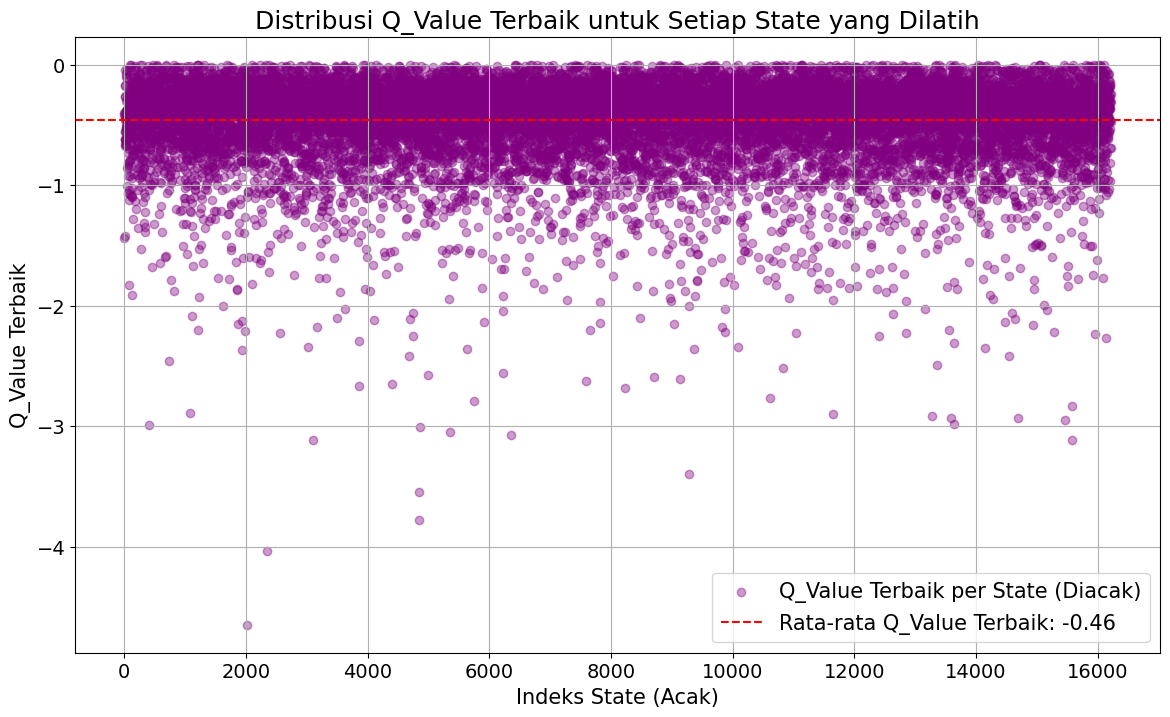

In [3]:
visualize_results_from_csv(tds_goal=600)